# Day 16 — Causation
### #30DayChartChallenge | April 2026

**The Policy That Saved the Ozone Layer.** The Montreal Protocol (1987) caused a 99% reduction in global consumption of ozone-depleting substances. Without it, an estimated 280 million skin cancer cases would have occurred.

**Data:** UNEP Ozone Secretariat via [Our World in Data](https://ourworldindata.org/grapher/consumption-of-ozone-depleting-substances) (indicator 577023)  
**Health impact:** US EPA  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: UNEP Ozone Secretariat via Our World in Data (indicator 577023)
# Global consumption of ozone-depleting substances in ODP tonnes

df <- read.csv("../../data/day_16/ods_consumption_world.csv",
               stringsAsFactors = FALSE)
names(df) <- c("year", "ods_odp_tonnes")

peak_year <- df$year[which.max(df$ods_odp_tonnes)]
peak_val <- max(df$ods_odp_tonnes)
latest_val <- df$ods_odp_tonnes[nrow(df)]
reduction <- round((1 - latest_val / peak_val) * 100, 1)

cat("Peak:", peak_year, "=", format(round(peak_val), big.mark = ","), "ODP tonnes\n")
cat("Latest:", df$year[nrow(df)], "=", format(round(latest_val), big.mark = ","), "ODP tonnes\n")
cat("Reduction:", reduction, "%\n")

Peak: 1989 = 1,662,589 ODP tonnes
Latest: 2021 = 16,622 ODP tonnes
Reduction: 99 %


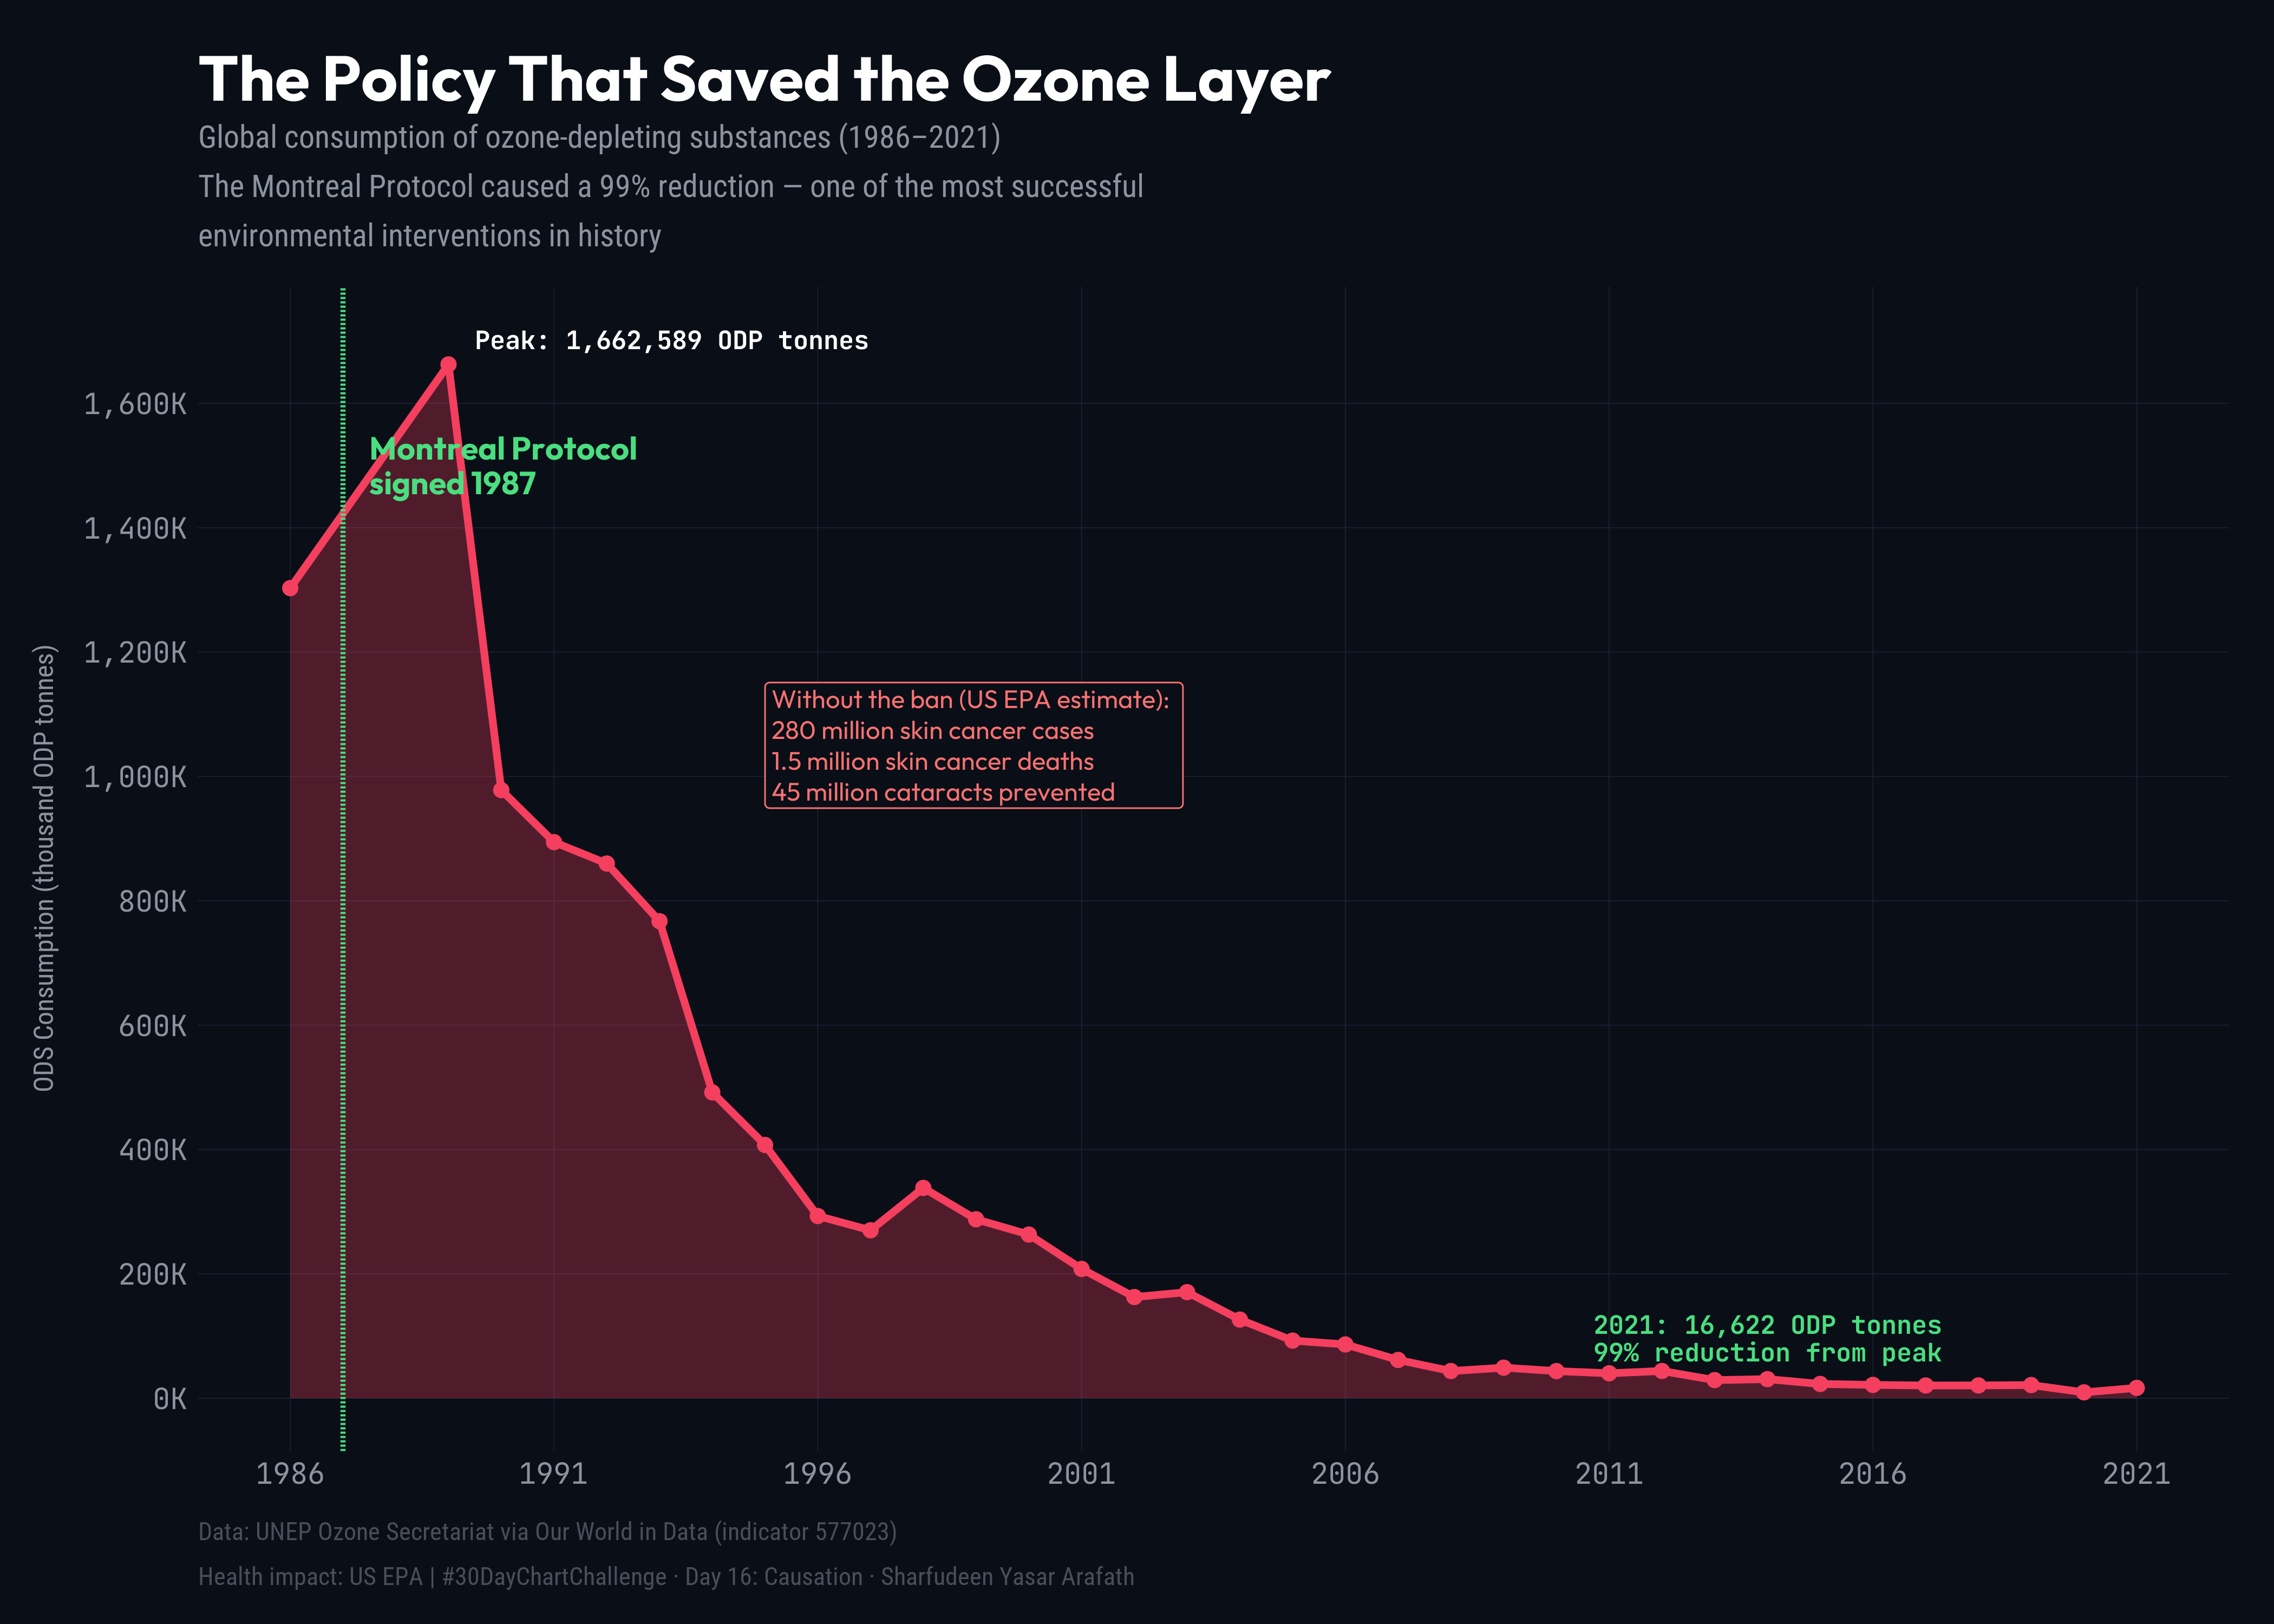

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

p <- ggplot(df, aes(x = year, y = ods_odp_tonnes / 1000)) +
  geom_area(fill = "#F43F5E", alpha = 0.3) +
  geom_line(color = "#F43F5E", linewidth = 1.2) +
  geom_point(color = "#F43F5E", size = 2.5) +

  geom_vline(xintercept = 1987, color = "#4ade80",
    linewidth = 0.8, linetype = "dashed") +
  annotate("text", x = 1987.5, y = 1500,
    label = "Montreal Protocol\nsigned 1987",
    family = "outfit", fontface = "bold", size = 5,
    color = "#4ade80", hjust = 0, lineheight = 0.9) +

  annotate("text", x = peak_year + 0.5, y = peak_val / 1000 + 40,
    label = paste0("Peak: ", format(round(peak_val), big.mark = ","),
      " ODP tonnes"),
    family = "jetbrains", size = 4, color = "#FFFFFF",
    fontface = "bold", hjust = 0) +

  annotate("text", x = 2014, y = latest_val / 1000 + 80,
    label = paste0("2021: ", format(round(latest_val), big.mark = ","),
      " ODP tonnes\n", reduction, "% reduction from peak"),
    family = "jetbrains", size = 4, color = "#4ade80",
    fontface = "bold", lineheight = 0.9) +

  annotate("label", x = 1995, y = 1050,
    label = paste0(
      "Without the ban (US EPA estimate):\n",
      "280 million skin cancer cases\n",
      "1.5 million skin cancer deaths\n",
      "45 million cataracts prevented"),
    family = "outfit", size = 4, color = "#f87171",
    fill = "#0a0e17DD", hjust = 0, lineheight = 1.0) +

  scale_x_continuous(breaks = seq(1986, 2021, 5)) +
  scale_y_continuous(
    labels = function(x) paste0(format(x, big.mark = ","), "K"),
    breaks = seq(0, 1800, 200)) +

  labs(
    title = "The Policy That Saved the Ozone Layer",
    subtitle = paste0(
      "Global consumption of ozone-depleting substances (1986\u20132021)\n",
      "The Montreal Protocol caused a 99% reduction \u2014 one of the most successful\n",
      "environmental interventions in history"
    ),
    x = NULL,
    y = "ODS Consumption (thousand ODP tonnes)",
    caption = paste0(
      "Data: UNEP Ozone Secretariat via Our World in Data (indicator 577023)\n",
      "Health impact: US EPA | ",
      "#30DayChartChallenge \u00b7 Day 16: Causation \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 28,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 11, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 15)),
    axis.text = element_text(size = 13, color = txt_dim, family = "jetbrains"),
    axis.title.y = element_text(size = 12, color = txt_dim,
      margin = margin(r = 10)),
    panel.grid.major = element_line(color = grid_col, linewidth = 0.15),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 20, 15, 15)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_16_causation.png",
       plot = p, width = 14, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_16_causation.png\n")

Done — saved to chart/day_16_causation.png
